In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
train_images = train_images.astype("float32") / 255
test_images = test_images.astype("float32") / 255
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


In [5]:
model.compile(optimizer="adam",
 loss="sparse_categorical_crossentropy",
 metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=15, batch_size=64, validation_split=0.2)




Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8057 - loss: 0.5413 - val_accuracy: 0.7925 - val_loss: 0.6029
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8182 - loss: 0.5097 - val_accuracy: 0.7909 - val_loss: 0.6244
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8184 - loss: 0.5066 - val_accuracy: 0.7971 - val_loss: 0.6021
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8211 - loss: 0.5003 - val_accuracy: 0.7840 - val_loss: 0.6330
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8246 - loss: 0.4885 - val_accuracy: 0.7955 - val_loss: 0.6112
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8294 - loss: 0.4802 - val_accuracy: 0.7874 - val_loss: 0.6389
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8321 - loss: 0.4608 - val_accuracy: 0.7983 - val_loss: 0.6124
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8372 - loss: 0.4594 - val_acc

In [6]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nFinal test accuracy: {test_acc:.4f}")


313/313 - 2s - 6ms/step - accuracy: 0.8041 - loss: 0.6302

Final test accuracy: 0.8041


In [7]:
import matplotlib.pyplot as plt
import numpy as np

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step


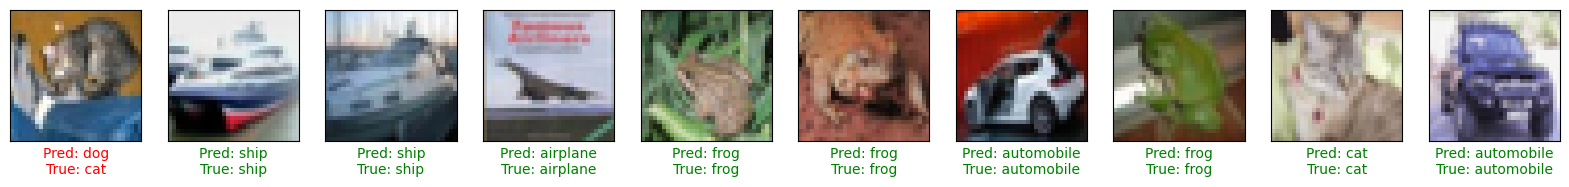

313/313 - 1s - 3ms/step - accuracy: 0.8041 - loss: 0.6302

Final test accuracy: 0.8041


In [8]:
(train_images_ori, train_labels_ori), (test_images_ori, test_labels_ori) = cifar10.load_data()
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
plt.figure(figsize=(20, 4))
for i in range(10):
  plt.subplot(1, 10, i+1)
  plt.imshow(test_images_ori[i])
  plt.xticks([])
  plt.yticks([])
  predicted_label_index = np.argmax(predictions[i])
  true_label_index = test_labels[i][0]
  predicted_class = class_names[predicted_label_index]
  true_class = class_names[true_label_index]
  color = 'green' if predicted_label_index == true_label_index else 'red'
  plt.xlabel(f"Pred: {predicted_class}\nTrue: {true_class}", color=color)
plt.show()
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nFinal test accuracy: {test_acc:.4f}")
